# 1. Feature Engineering (Test on 1 stock)

### Import Data

In [130]:
from pathlib import Path
import sys
import pandas as pd

# Add src as part of the import system also
sys.path.append(str(Path.cwd().parent / 'src'))

from config import RAW_DATA_PATH

df = pd.read_csv(RAW_DATA_PATH / 'all_stocks_combined.csv')

df['Date'] = pd.to_datetime(df['Date'])

### Quick Check

In [131]:
df.head()

,Date,Close,High,Low,Open,Volume,Ticker,Name
0,2018-01-02,5.563982,5.575502,5.523663,5.558222,5284100,1155.KL,Maybank
1,2018-01-03,5.633101,5.633101,5.563983,5.563983,13946300,1155.KL,Maybank
2,2018-01-04,5.644619,5.656139,5.633100,5.633100,18711500,1155.KL,Maybank
3,2018-01-05,5.644619,5.656139,5.638860,5.644619,17266600,1155.KL,Maybank
4,2018-01-08,5.673418,5.673418,5.638858,5.644618,19238800,1155.KL,Maybank


In [132]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25107 entries, 0 to 25106
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    25107 non-null  datetime64[us]
 1   Close   25107 non-null  float64       
 2   High    25107 non-null  float64       
 3   Low     25107 non-null  float64       
 4   Open    25107 non-null  float64       
 5   Volume  25107 non-null  int64         
 6   Ticker  25107 non-null  str           
 7   Name    25107 non-null  str           
dtypes: datetime64[us](1), float64(4), int64(1), str(2)
memory usage: 1.9 MB


In [133]:
df['Ticker'].unique()

<ArrowStringArray>
['1155.KL', '1295.KL', '1023.KL', '1066.KL', '5819.KL', '1015.KL', '2488.KL',
 '5185.KL', '5258.KL',  'D05.SI',  'O39.SI',  'U11.SI']
Length: 12, dtype: str

In [134]:
df.isnull().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
Ticker    0
Name      0
dtype: int64

### Testing Visualization

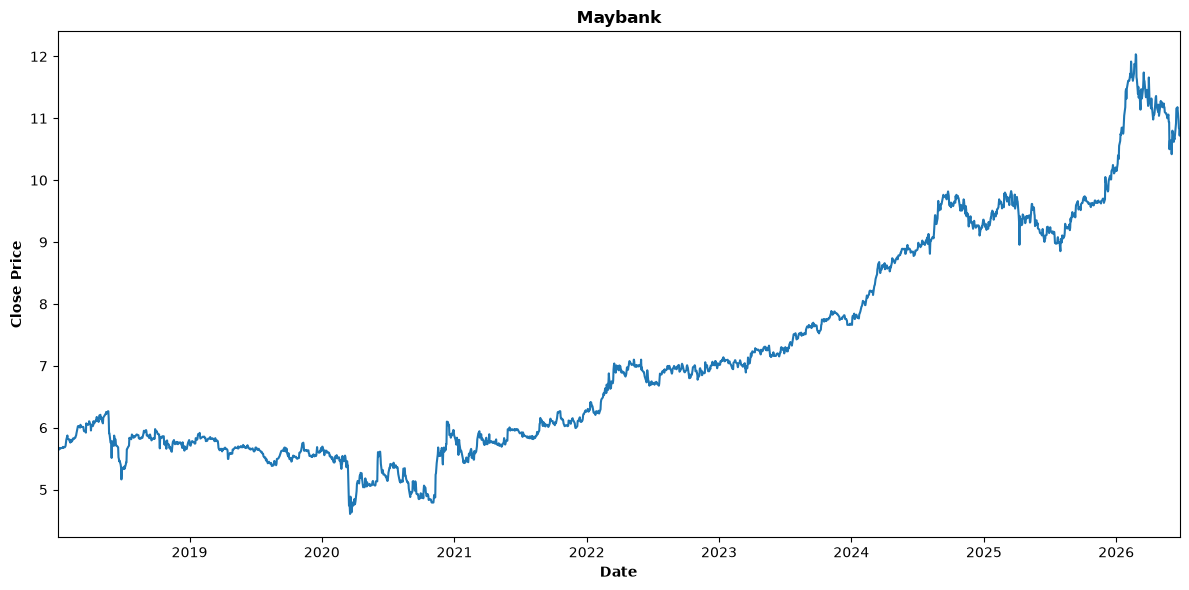

In [135]:
import matplotlib.pyplot as plt

maybank = df[df['Ticker'] == '1155.KL'].copy()

plt.figure(figsize=(12,6))

plt.plot(maybank['Date'], maybank['Close'])

plt.title('Maybank', fontweight = 'bold')
plt.xlabel('Date', fontweight = 'bold')
plt.ylabel('Close Price', fontweight = 'bold')

plt.xlim(maybank['Date'].min(), maybank['Date'].max()) # restricting the range

plt.tight_layout()
plt.show()

### Features (Basics)

#### Returns

In [136]:
maybank['returns'] = maybank['Close'].pct_change()

maybank['returns'].head()

0         NaN
1    0.012422
2    0.002045
3    0.000000
4    0.005102
Name: returns, dtype: float64

- Returns is calculated by current row vs previous row.
- Row 0 is NaN (correct because it doesn't have previous row)

#### Simple Moving Average (SMA)

In [137]:
maybank['sma_20'] = maybank['Close'].rolling(window = 20).mean()
maybank['sma_50'] = maybank['Close'].rolling(window = 50).mean()

maybank[['Date', 'Close', 'sma_20', 'sma_50']].tail()

,Date,Close,sma_20,sma_50
2074,2026-06-22,10.96,10.815,11.0176
2075,2026-06-23,10.84,10.807,11.0112
2076,2026-06-24,10.82,10.795,11.0044
2077,2026-06-25,10.72,10.784,10.9992
2078,2026-06-26,10.80,10.777,10.9944


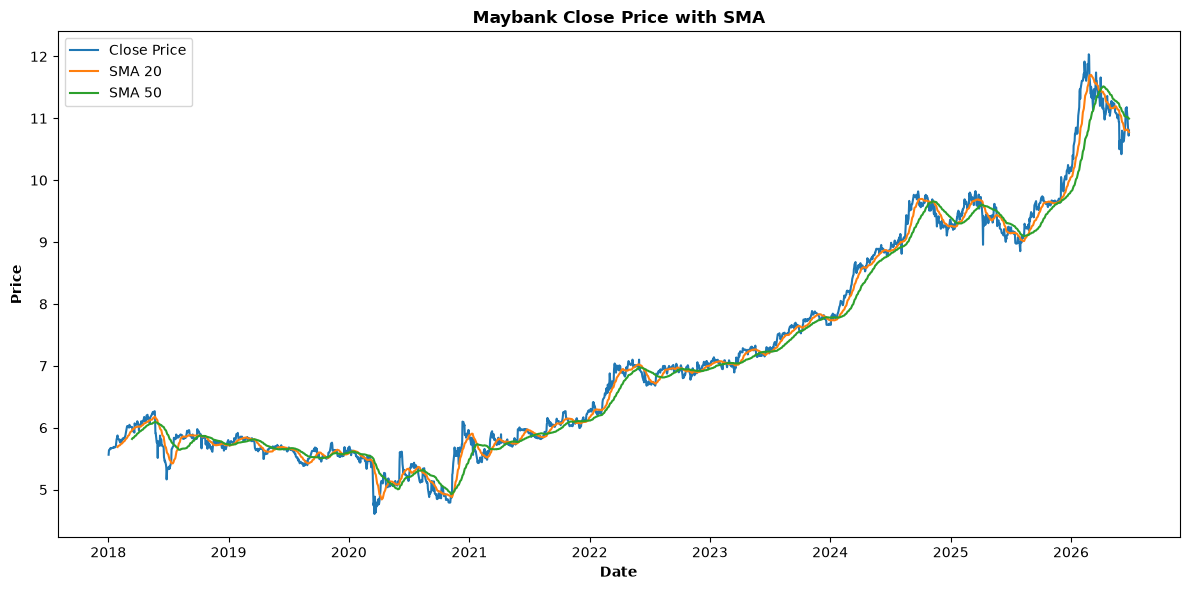

In [138]:
plt.figure(figsize=(12,6))

plt.plot(maybank['Date'], maybank['Close'], label = 'Close Price')
plt.plot(maybank['Date'], maybank['sma_20'], label = 'SMA 20')
plt.plot(maybank['Date'], maybank['sma_50'], label = 'SMA 50')

plt.title('Maybank Close Price with SMA', fontweight = 'bold')
plt.xlabel('Date', fontweight = 'bold')
plt.ylabel('Price', fontweight = 'bold')
plt.legend()

plt.tight_layout()
plt.show()

- SMA_20 calculates 20 days simple moving average of the closing price.
- SMA_50 calculates 50 days simple moving average of the closing price.
- Therefore, the close price is the most volatile, SMA_20 is smoother, and SMA_50 is the smoothest.
- The plot confirms that they are calculated correctly.

*Note: SMA = all past prices equal weight*

#### Exponential Moving Average (EMA)

In [139]:
maybank['ema_20'] = maybank['Close'].ewm(span=20, adjust=False).mean()
maybank['ema_50'] = maybank['Close'].ewm(span=50, adjust=False).mean()

maybank[['Date', 'Close', 'ema_20', 'ema_50']].head()

,Date,Close,ema_20,ema_50
0,2018-01-02,5.563982,5.563982,5.563982
1,2018-01-03,5.633101,5.570565,5.566693
2,2018-01-04,5.644619,5.577618,5.569748
3,2018-01-05,5.644619,5.583999,5.572685
4,2018-01-08,5.673418,5.592515,5.576635


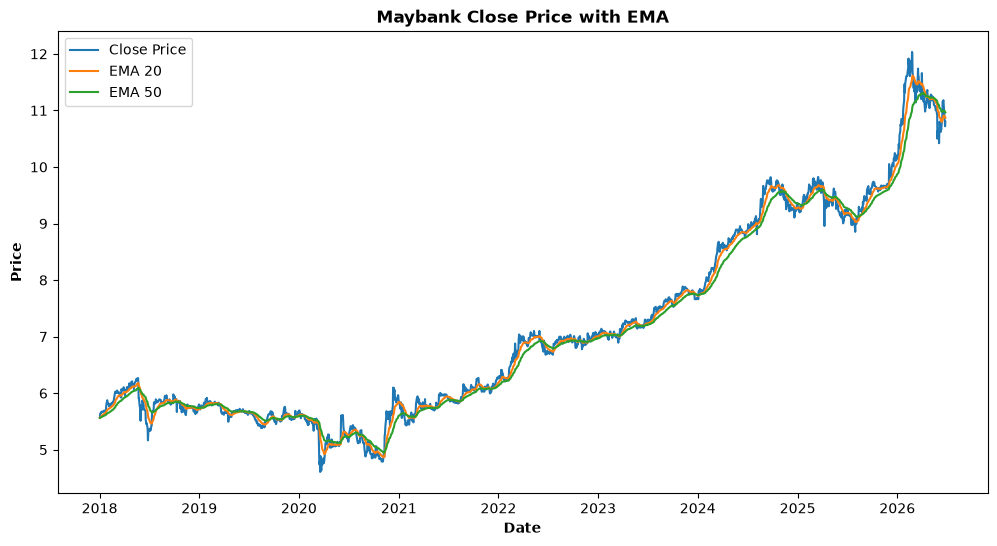

In [140]:
plt.figure(figsize=(12,6))

plt.plot(maybank['Date'], maybank['Close'], label = 'Close Price')
plt.plot(maybank['Date'], maybank['ema_20'], label = 'EMA 20')
plt.plot(maybank['Date'], maybank['ema_50'], label = 'EMA 50')

plt.title('Maybank Close Price with EMA', fontweight = 'bold')
plt.xlabel('Date', fontweight = 'bold')
plt.ylabel('Price', fontweight = 'bold')

plt.legend()
plt.show()

- EMA_20 calculates 20 days exponential moving average which is giving higher weight to recent prices.
- EMA_50 calculates 50 days exponential moving average which is capturing a longer term trend with more responsiveness than SMA.
- EMA_20 follows price movements more closely, while EMA_50 provides a smoother long term trend indicator.
- The plot confirms that they are calculated correctly.

*Note: EMA = more recent prices matter more*

#### Volume Feature

In [141]:
maybank['volume_sma_20'] = maybank['Volume'].rolling(20).mean()

In [142]:
maybank[['Date', 'Close', 'volume_sma_20']].tail()

,Date,Close,volume_sma_20
2074,2026-06-22,10.96,15069525.0
2075,2026-06-23,10.84,14763265.0
2076,2026-06-24,10.82,14727330.0
2077,2026-06-25,10.72,14697085.0
2078,2026-06-26,10.80,15043440.0


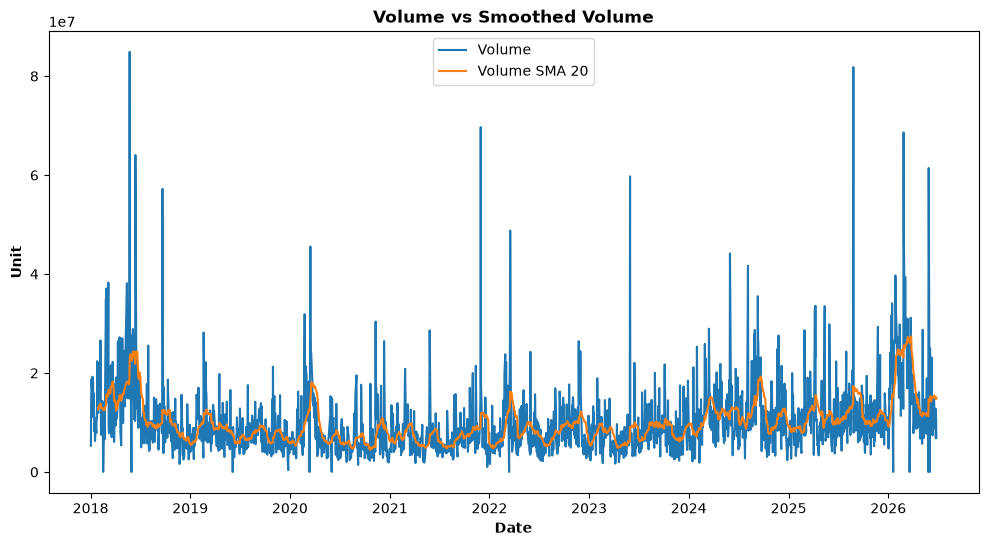

In [143]:
plt.figure(figsize=(12,6))

plt.plot(maybank['Date'], maybank['Volume'], label = 'Volume')
plt.plot(maybank['Date'], maybank['volume_sma_20'], label = 'Volume SMA 20')

plt.title('Volume vs Smoothed Volume', fontweight = 'bold')
plt.xlabel('Date', fontweight = 'bold')
plt.ylabel('Unit', fontweight = 'bold')

plt.legend()
plt.show()

- Smooths trading activity.
- Helps to detect unusual volume spikes.
- Plot looks correct.

### Features (Technical Indicators)

#### Relative Strength Index (RSI)

In [144]:
import pandas_ta as ta

maybank['rsi'] = ta.rsi(maybank['Close'], length = 14) # look back last 14 days

In [145]:
maybank[['Date', 'Close', 'rsi']].head(20)

,Date,Close,rsi
0,2018-01-02,5.563982,NaN
1,2018-01-03,5.633101,100.000000
2,2018-01-04,5.644619,100.000000
3,2018-01-05,5.644619,100.000000
4,2018-01-08,5.673418,100.000000
5,2018-01-09,5.661897,98.497810
6,2018-01-10,5.667657,98.509863
7,2018-01-11,5.667657,98.509863
8,2018-01-12,5.673418,98.523602
9,2018-01-15,5.673418,98.523602


*Note: pandas-ta uses **Wilder’s smoothing (RMA)**: Starts building averages gradually which means it doesn't wait for a full 14-day block like a rolling mean. Therefore NaNs will be lesser instead of what we expected from textbook RSI (having 14 NaNs)*

In [146]:
maybank['rsi'].describe()

count    2078.000000
mean       53.870410
std        12.332196
min        17.761082
25%        45.403326
50%        53.239558
75%        61.650374
max       100.000000
Name: rsi, dtype: float64

**RSI meaning:**

- 0–30 → oversold (too cheap, may bounce up)
- 30–70 → normal zone
- 70–100 → overbought (too expensive, may drop)

*Note: Must be 0-100, describe above confirms that*
   

#### Momentum Trend Indicator (MACD)

In [147]:
#12, 26, and 9 are the standard, textbook defaults introduced by Gerald Appel
maybank['macd'] = ta.macd(maybank['Close'])['MACD_12_26_9']
maybank['macd_signal'] = ta.macd(maybank['Close'])['MACDs_12_26_9']
maybank['macd_diff'] = ta.macd(maybank['Close'])['MACDh_12_26_9']

In [148]:
maybank[['Date','macd','macd_signal','macd_diff']].tail(10)

,Date,macd,macd_signal,macd_diff
2069,2026-06-12,-0.127698,-0.133301,0.005603
2070,2026-06-15,-0.102418,-0.127124,0.024706
2071,2026-06-16,-0.062300,-0.114159,0.051860
2072,2026-06-18,-0.030158,-0.097359,0.067201
2073,2026-06-19,-0.003036,-0.078494,0.075458
2074,2026-06-22,0.000697,-0.062656,0.063353
2075,2026-06-23,-0.005958,-0.051316,0.045358
2076,2026-06-24,-0.012700,-0.043593,0.030893
2077,2026-06-25,-0.025814,-0.040037,0.014223
2078,2026-06-26,-0.029413,-0.037913,0.008499


**MACD meaning:**

- MACD > signal → bullish momentum
- MACD < signal → bearish momentum
- Diff = strength of movement

*Note: MACD values fluctuate around zero. Correct*

#### Bollinger Bands

In [149]:
bb = ta.bbands(maybank['Close'], length=20)

maybank['bb_low'] = bb['BBL_20_2.0_2.0']
maybank['bb_mid'] = bb['BBM_20_2.0_2.0']
maybank['bb_high'] = bb['BBU_20_2.0_2.0']

In [150]:
maybank[['Close', 'bb_low', 'bb_mid', 'bb_high']].tail(10)

,Close,bb_low,bb_mid,bb_high
2069,10.72,10.373121,10.814,11.254880
2070,10.92,10.381705,10.805,11.228295
2071,11.16,10.373429,10.809,11.244571
2072,11.16,10.365641,10.813,11.260359
2073,11.18,10.354791,10.819,11.283210
2074,10.96,10.357478,10.815,11.272522
2075,10.84,10.357575,10.807,11.256425
2076,10.82,10.361483,10.795,11.228517
2077,10.72,10.354832,10.784,11.213168
2078,10.80,10.354023,10.777,11.199977


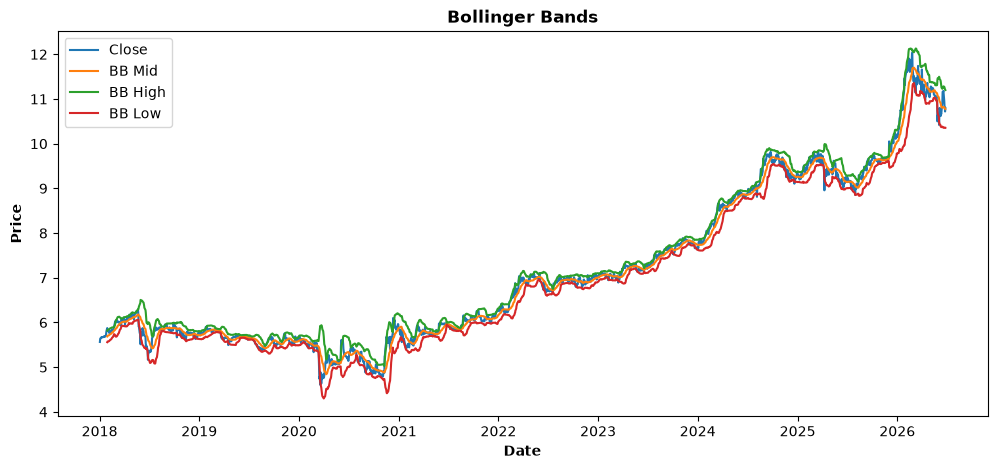

In [151]:
plt.figure(figsize=(12,5))

plt.plot(maybank['Date'], maybank['Close'], label = 'Close')
plt.plot(maybank['Date'], maybank['bb_mid'], label = 'BB Mid')
plt.plot(maybank['Date'], maybank['bb_high'], label = 'BB High')
plt.plot(maybank['Date'], maybank['bb_low'], label = 'BB Low')

plt.title('Bollinger Bands', fontweight = 'bold')
plt.xlabel('Date', fontweight = 'bold')
plt.ylabel('Price', fontweight = 'bold')

plt.legend()
plt.show()

**BB meaning:**

- Upper band → expensive zone
- Lower band → cheap zone
- Middle → trend average

*Note: bb_low < bb_mid < bb_high, correct*

### Check Maybank columns

In [152]:
maybank.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker', 'Name',
       'returns', 'sma_20', 'sma_50', 'ema_20', 'ema_50', 'volume_sma_20',
       'rsi', 'macd', 'macd_signal', 'macd_diff', 'bb_low', 'bb_mid',
       'bb_high'],
      dtype='str')

In [153]:
maybank.isnull().sum()

Date              0
Close             0
High              0
Low               0
Open              0
Volume            0
Ticker            0
Name              0
returns           1
sma_20           19
sma_50           49
ema_20            0
ema_50            0
volume_sma_20    19
rsi               1
macd             25
macd_signal      33
macd_diff        33
bb_low           19
bb_mid           19
bb_high          19
dtype: int64

**Expected numbers of NaNs. Correct.**

# 2. Feature Engineering (All stocks)

In [154]:
def add_features(df):
    df = df.copy()

    # returns
    df['returns'] = df['Close'].pct_change()

    # SMA
    df['sma_20'] = df['Close'].rolling(20).mean()
    df['sma_50'] = df['Close'].rolling(50).mean()

    # EMA
    df['ema_20'] = df['Close'].ewm(span=20, adjust=False).mean()
    df['ema_50'] = df['Close'].ewm(span=50, adjust=False).mean()

    # volume SMA
    df['volume_sma'] = df['Volume'].rolling(20).mean()

    # RSI
    df['rsi'] = ta.rsi(df['Close'], length=14)

    # MACD
    macd = ta.macd(df['Close'])
    df['macd'] = macd['MACD_12_26_9']
    df['macd_signal'] = macd['MACDs_12_26_9']
    df['macd_diff'] = macd['MACDh_12_26_9']

    # Bollinger Bands
    bb = ta.bbands(df['Close'], length=20)
    df['bb_low'] = bb['BBL_20_2.0_2.0']
    df['bb_mid'] = bb['BBM_20_2.0_2.0']
    df['bb_high'] = bb['BBU_20_2.0_2.0']

    return df

In [155]:
# Applying the features function to each of the stock group one by one 
df = df.groupby('Ticker', group_keys = False).apply(add_features)

### Check nulls

In [156]:
df.isnull().sum()

Date             0
Close            0
High             0
Low              0
Open             0
Volume           0
Name             0
returns         12
sma_20         228
sma_50         588
ema_20           0
ema_50           0
volume_sma     228
rsi             14
macd           300
macd_signal    396
macd_diff      396
bb_low         228
bb_mid         228
bb_high        228
dtype: int64

### Drop nulls

In [157]:
df = df.dropna()

df.isnull().sum()

Date           0
Close          0
High           0
Low            0
Open           0
Volume         0
Name           0
returns        0
sma_20         0
sma_50         0
ema_20         0
ema_50         0
volume_sma     0
rsi            0
macd           0
macd_signal    0
macd_diff      0
bb_low         0
bb_mid         0
bb_high        0
dtype: int64

In [158]:
df.shape

(24519, 20)

**Acceptable data loss**

# 3. Target Variable

In [159]:
df['target'] = (df['Close'].shift(-1) - df['Close'] > 0).astype(int)

In [160]:
df[['Date', 'Close', 'target']].tail(10)

,Date,Close,target
25097,2026-06-15,38.450001,1
25098,2026-06-16,39.000000,1
25099,2026-06-17,39.349998,1
25100,2026-06-18,39.700001,0
25101,2026-06-19,39.250000,1
25102,2026-06-22,39.459999,1
25103,2026-06-23,39.840000,1
25104,2026-06-24,39.900002,1
25105,2026-06-25,39.910000,0
25106,2026-06-26,39.799999,0


**Target:**

- 1: price goes up tomorrow
- 0: price goes down tomorrow / no changes
- The last row should be NaN here, but because of the comparison **NaN > Close → False**, it is converted to 0
- the last row should be removed as it is not valid.

In [161]:
df = df.iloc[:-1] # removes the last row

In [162]:
df[['Date', 'Close', 'target']].tail(10)

,Date,Close,target
25096,2026-06-12,38.160000,1
25097,2026-06-15,38.450001,1
25098,2026-06-16,39.000000,1
25099,2026-06-17,39.349998,1
25100,2026-06-18,39.700001,0
25101,2026-06-19,39.250000,1
25102,2026-06-22,39.459999,1
25103,2026-06-23,39.840000,1
25104,2026-06-24,39.900002,1
25105,2026-06-25,39.910000,0


**Looks good now**